In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def load_data(path):
    """Reads whitespace-separated numeric data (one point per line)."""
    data = np.loadtxt(path)
    return data

data = load_data("data_k_mean.txt")
print(f"Loaded {data.shape[0]} points with {data.shape[1]} features.")

Loaded 3000 points with 2 features.


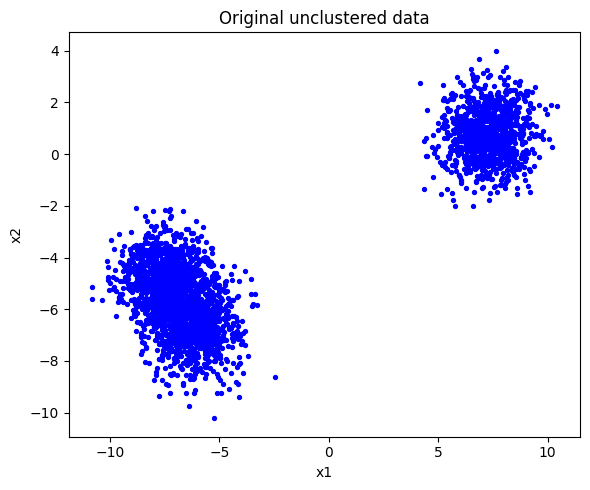

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(data[:, 0], data[:, 1], s=8, c="blue")
plt.title("Original unclustered data")
plt.xlabel("x1")
plt.ylabel("x2")
plt.tight_layout()
plt.show()

In [ ]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2, axis=1))


def k_means(data, k, max_iters=100, random_state=42): # The answer to life, universe and everything
    rng = np.random.default_rng(random_state)

    initial_idx = rng.choice(len(data), size=k, replace=False)
    centroids = data[initial_idx].copy()

    labels = np.zeros(len(data), dtype=int)

    for iteration in range(max_iters):
        distances = np.zeros((k, len(data)))
        for ci in range(k):
            distances[ci] = euclidean_distance(data, centroids[ci])

        new_labels = np.argmin(distances, axis=0)

        if iteration > 0 and np.array_equal(new_labels, labels):
            labels = new_labels
            print(f"Converged after {iteration} iterations.")
            break

        labels = new_labels

        new_centroids = np.zeros_like(centroids)
        for ci in range(k):
            members = data[labels == ci]
            if len(members) > 0:
                new_centroids[ci] = members.mean(axis=0)
            else:
                new_centroids[ci] = data[rng.integers(len(data))]
        centroids = new_centroids
    else:
        print(f"Stopped after reaching max_iters = {max_iters}.")

    return labels, centroids

In [ ]:
K = 2
labels, centroids = k_means(data, k=K, random_state=42)

print("Final centroids:")
print(centroids)
print("Cluster sizes:", np.bincount(labels))

Converged after 1 iterations.
Final centroids:
[[ 7.21831715  0.78213112]
 [-6.81708973 -5.72084663]]
Cluster sizes: [1000 2000]


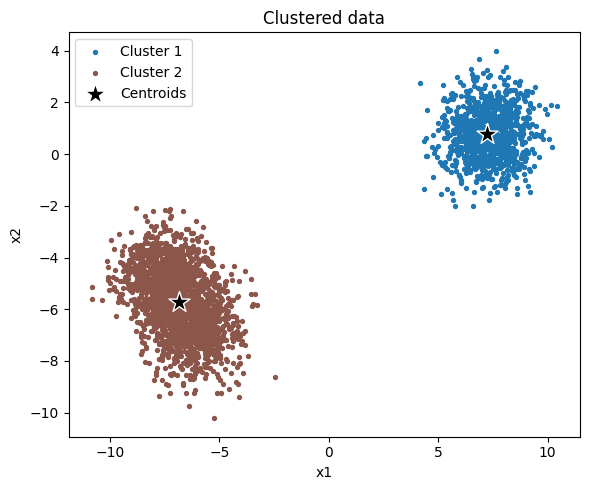

In [ ]:
def plot_clusters(data, labels, centroids, title="Clustered data"):
    k = centroids.shape[0]
    colors = plt.cm.tab10(np.linspace(0, 1, max(k, 3)))

    plt.figure(figsize=(6, 5))
    for ci in range(k):
        pts = data[labels == ci]
        plt.scatter(pts[:, 0], pts[:, 1], s=8, color=colors[ci], label=f"Cluster {ci + 1}")
    plt.scatter(centroids[:, 0], centroids[:, 1], marker="*", s=250,
                c="black", edgecolors="white", linewidths=1, label="Centroids")
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_clusters(data, labels, centroids)

Converged after 11 iterations.


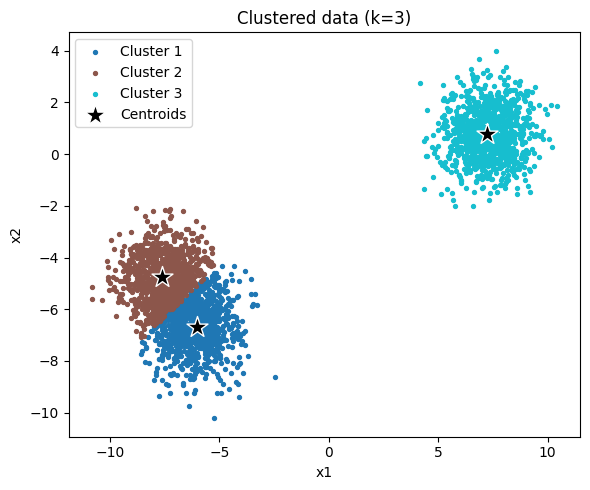

In [ ]:
labels3, centroids3 = k_means(data, k=3, random_state=0)
plot_clusters(data, labels3, centroids3, title="Clustered data (k=3)")

Data Points for txt file:

-7.87157 -4.86573
-4.76661 -6.87944
-6.67986 -5.83080
-8.93021 -4.15571
-7.91375 -4.22840
5.86288 0.99790
-7.61570 -6.00562
8.07681 0.16283
5.76394 -0.44060
-5.04527 -6.04326
-5.94523 -7.27719
7.68229 1.87321
-7.16451 -4.55707
-5.52871 -6.98528
-5.15767 -4.79025
-6.58077 -6.98098
6.91940 1.86407
-6.63833 -5.22404
7.84315 0.71741
-8.62059 -4.52196
7.71381 0.67403
7.55081 -0.13926
-6.12205 -6.32135
-8.52419 -3.80650
-6.61174 -7.29484
5.96309 1.11874
-5.48900 -5.65873
-7.88635 -6.18173
-6.94976 -3.67368
-8.63254 -6.52590
-5.89133 -7.04173
-5.55773 -4.03560
-9.97112 -4.99721
8.43324 2.47093
7.60951 1.76459
-6.03485 -7.29275
-5.24465 -4.92922
-6.23370 -4.43883
-7.34628 -4.62276
7.75075 0.20362
-6.27746 -7.31230
-4.95842 -8.74122
-6.97291 -3.93948
7.52364 -0.33405
7.49952 1.14129
-6.78744 -6.05966
-7.77610 -4.20971
6.38471 1.28031
7.01216 -0.97186
-8.45264 -5.34712
6.83194 -0.22807
-7.07633 -4.87534
-7.69028 -6.05465
-6.08345 -7.02255
7.94207 0.94220
-5.91793 -6.62436
-8.44297 -5.29826
-6.29140 -5.34205
-7.49168 -5.44177
8.04116 -1.15421
-6.46121 -5.94005
-6.81407 -5.54108
-8.79281 -6.82649
-8.09321 -3.21876
-6.41933 -6.08123
-4.62398 -6.29054
-8.25562 -6.38824
-7.95317 -5.45339
5.87246 1.47816
-4.66782 -7.99246
-7.32159 -5.78078
-6.53911 -5.01311
-7.16620 -5.07137
6.85442 0.44330
6.51556 3.28252
6.55113 0.69826
-6.43144 -6.03970
-8.50554 -6.00009
-5.73843 -5.23288
-5.88533 -5.67933
-5.89665 -7.28911
-5.14793 -4.70658
-5.39689 -6.18066
-8.25693 -5.31355
-10.78821 -5.13448
-7.75734 -5.68653
-6.39394 -6.90087
-6.78361 -7.46939
-6.91061 -7.63184
8.99541 0.14477
5.63340 -1.50105
9.42725 0.68575
-5.62166 -5.68311
7.58128 1.16479
-7.20192 -5.57663
7.23950 0.53404
-6.40588 -5.47509
-4.08051 -7.85450
6.50260 1.32525
-5.39180 -6.65102
-5.32268 -7.06183
7.51129 0.13791
6.62927 0.17088
-7.68473 -5.98168
-5.89266 -6.40242
-9.16682 -4.56016
-8.53587 -3.50102
7.53026 -0.18052
-6.78317 -4.41377
-5.52670 -7.76432
-7.77124 -4.72296
-7.30225 -6.95752
-6.13518 -8.65277
7.28518 2.97565
-7.86096 -6.92948
7.49795 0.00129
-5.93595 -5.78437
7.10849 1.30414
-8.82496 -5.79621
-5.53145 -8.05101
-6.34679 -6.77338
-7.38967 -4.13807
-7.96624 -5.91066
-5.63694 -7.34339
-5.83266 -7.30880
7.41310 0.54604
-6.33354 -8.70331
-8.70567 -5.05602
-8.66779 -4.30055
-6.59270 -6.48088
8.18502 2.97817
8.09507 1.67439
-6.50974 -7.16775
6.93048 1.54301
-6.76859 -5.28742
7.62956 0.16259
-9.15115 -4.26442
-6.44804 -4.98288
6.38693 2.14640
6.84131 1.47841
6.87510 0.68112
-7.04017 -4.29597
-8.76262 -5.24134
-6.67053 -3.91587
5.87592 0.06363
-7.25162 -2.12642
-5.57650 -7.37046
5.48667 -0.13535
7.21738 2.03555
-5.54107 -6.26420
-8.37328 -4.77283
-7.82786 -4.90443
-5.58792 -8.20800
-10.09256 -4.87564
8.09676 3.38070
-6.89615 -6.26886
-8.21536 -3.74022
6.70012 0.37225
8.36514 -0.54768
-7.52931 -5.69324
-7.61428 -6.32945
9.97287 1.55972
8.04263 0.30057
7.24479 -0.18872
-6.76028 -7.39174
9.22864 0.81013
6.53354 0.06489
-8.26586 -3.98115
7.10882 1.29766
5.17969 -0.41467
-8.40297 -2.39503
-5.83112 -5.59009
9.33258 1.77344
-5.05899 -7.66152
6.97194 1.65105
6.18861 -0.07991
7.07483 0.12866
6.62398 -0.26419
-6.34288 -7.67599
8.19485 0.77298
-6.64705 -3.93545
-5.69921 -6.53435
7.25337 0.38509
-7.70640 -5.93587
-6.45338 -7.72224
-8.81450 -3.50024
-5.88477 -6.43539
-6.94572 -5.01141
7.20423 1.32339
6.05054 0.96120
6.54221 0.52859
-7.91049 -6.69173
7.16663 1.48895
-7.61220 -3.81858
-6.93561 -6.46205
-8.64239 -3.68078
-8.03201 -4.90374
-6.80462 -4.96326
-10.82103 -5.62327
5.67927 1.23994
5.67849 2.28385
-6.54707 -7.14870
-6.24441 -7.75225
-7.01634 -7.60708
-8.18271 -5.80181
-6.61415 -6.26521
-6.92465 -6.74620
-8.15421 -5.90451
-6.37291 -7.16988
7.35691 -1.50357
-7.23691 -9.25470
-6.73512 -3.55145
-5.05574 -7.06048
-7.87718 -4.97877
8.11047 -0.23666
5.32905 -0.51702
-6.19672 -5.29635
-4.23632 -6.89803
8.09377 -0.13412
-7.51093 -5.65001
-7.94990 -5.34122
7.78556 -0.37468
-5.48598 -6.65094
6.67626 0.74652
-7.07543 -5.55318
6.49838 1.20616
-6.83296 -6.63673
7.32125 0.29450
7.23608 1.27433
6.77448 -0.86579
-8.88965 -5.69741
-7.35491 -7.18989
-4.50599 -5.70086
-4.64981 -6.32073
5.39397 0.82962
-6.35345 -4.91818
-7.20773 -7.63569
-8.04471 -5.24974
-4.89860 -6.75821
9.36099 0.06115
-6.67959 -5.20557
-7.79799 -4.72503
-5.09408 -6.95496
-6.61151 -4.07999
-5.29482 -7.34976
10.41346 1.86626
-6.76879 -5.70227
8.16297 1.64667
7.25815 0.30505
7.08967 1.80445
-6.93030 -5.53940
-9.18932 -4.81291
-5.08508 -6.77804
8.05281 0.91528
-5.97139 -7.82418
6.49295 0.72898
-6.75422 -5.67426
8.55146 -0.88666
6.99423 1.00618
7.81615 0.13034
-5.83931 -5.96107
-7.46372 -5.39503
6.55404 1.02688
8.87217 1.39649
-7.17487 -5.41725
-8.04758 -3.99094
5.97448 1.08628
8.25467 -0.08952
8.10846 -1.06128
5.55578 0.06438
7.26601 1.79407
6.03877 -1.11883
7.61587 0.99744
-8.23733 -3.85163
-6.74879 -3.96691
7.93836 0.85349
6.78937 0.40372
5.40006 2.05194
7.30360 1.77391
-8.06536 -4.36862
-7.57686 -2.63304
-7.13287 -7.03877
8.05839 1.02435
-9.37394 -4.50491
-8.48863 -6.63527
-5.89912 -6.02699
-6.66784 -8.07040
-5.55758 -7.28761
-7.83139 -4.82040
9.13361 1.39940
6.90305 -0.19237
6.35297 0.62534
6.52264 1.68080
7.29116 0.55413
-4.80799 -8.88665
-8.08501 -6.47710
7.94849 3.22792
-7.49050 -6.90334
-7.58973 -6.85670
-7.82615 -7.59466
6.98758 -1.29308
-4.33636 -4.32968
6.30885 1.09275
-8.41975 -7.28950
-6.90626 -6.98819
6.63142 1.07877
-5.23939 -6.80098
-5.45664 -7.04631
-6.45850 -8.06936
-7.10334 -4.88950
-5.66104 -4.13877
-9.69305 -5.27849
-3.55745 -4.83566
8.90186 1.14683
-4.39944 -5.64849
-7.58085 -5.43134
6.40111 -0.36628
7.97192 0.93684
-6.78602 -5.78885
5.39328 -1.34910
7.72314 1.08014
-8.25655 -6.21408
-6.17647 -4.85353
-6.43949 -3.74911
-7.64828 -3.68973
-7.04141 -4.83292
-5.31763 -6.06146
-5.03977 -7.20681
-5.27153 -6.24642
-5.50183 -7.28210
-6.97727 -5.84930
9.26935 2.40710
7.30911 0.76093
-6.91578 -6.48923
-5.71706 -7.22400
7.19550 0.36270
7.87244 0.35966
8.14453 1.15207
-7.65292 -3.71430
7.03091 0.88759
7.73593 1.23622
-4.37782 -7.09134
-5.99038 -3.68549
-5.67270 -6.93910
-7.10978 -3.65242
-5.95998 -4.46727
6.41056 0.99079
-7.39938 -4.93191
7.29242 -0.80792
-6.33979 -6.67702
7.69704 1.80052
-7.58269 -5.71548
-8.25291 -4.81794
-8.89296 -5.01927
10.17858 0.27113
7.21847 1.67278
-6.12216 -8.39688
7.72245 1.79989
6.36879 1.62242
-7.55662 -5.61609
8.26480 0.23060
-3.90529 -8.46065
-6.80197 -6.26808
6.88194 0.94249
6.22214 1.56522
-8.60126 -4.27322
-5.26176 -6.35219
-8.09281 -3.60302
6.38539 2.14355
-7.24136 -4.34680
6.31790 0.94836
-7.61910 -4.91109
-6.71059 -5.49650
-5.36922 -6.17654
-7.18447 -6.30512
-8.18717 -3.71239
4.47906 1.70205
-6.07363 -5.10841
8.88720 0.81433
-6.92481 -6.37577
-6.95549 -4.23830
-8.75453 -4.77751
-7.71468 -5.59514
-5.49386 -5.67898
7.96976 1.20466
-7.10242 -4.22290
-7.97340 -6.69597
5.68075 -1.76609
-6.33702 -7.53815
-6.10587 -8.19320
6.30758 2.05073
-4.91264 -5.55436
6.95402 -0.80951
-7.49465 -4.05643
7.28601 1.52458
6.70856 0.92073
-6.75398 -4.82830
7.02135 -0.18250
-6.61104 -6.81826
-5.70298 -5.02027
-5.80979 -7.36692
-5.31614 -4.83682
7.24001 3.26840
-4.93809 -7.23888
-8.91548 -5.18548
6.54256 1.24288
-6.03580 -7.85297
-8.43785 -5.13207
7.93299 2.18974
-6.69400 -4.22417
-6.87049 -5.20869
-6.86065 -3.79692
-7.07154 -5.87550
-6.42892 -3.63781
-6.36463 -4.43467
-6.31696 -7.47543
-8.25066 -6.52162
-7.99866 -3.77267
-6.89869 -5.61073
-7.72674 -5.73494
-7.97163 -5.71463
-8.00083 -2.95298
-3.80864 -7.37921
-7.41792 -5.32526
-4.77391 -5.24894
-8.64028 -5.74375
9.42710 2.58726
-5.09280 -6.71812
-7.56993 -4.91579
7.84549 0.63061
-6.42884 -7.91260
-6.07124 -6.14216
-5.66335 -7.61748
-4.89568 -6.75886
-6.70735 -7.26456
-6.67144 -6.95530
6.05919 0.21211
7.93852 2.17908
8.12528 -0.63093
-6.99595 -5.24685
7.63922 1.98181
-4.23777 -6.91279
-6.21897 -5.54003
7.87036 1.04169
-7.34321 -4.75543
7.36057 0.00131
8.44342 -0.13144
7.74318 0.45247
-4.19079 -8.23503
-7.04517 -7.20843
-5.13009 -7.61021
-7.92860 -4.99412
-7.03303 -4.75125
-7.62565 -5.20235
-8.83049 -4.50830
-6.62743 -7.28098
-5.49818 -6.26208
9.20729 1.98380
-7.49852 -5.02819
-6.52698 -5.84838
-6.76388 -5.41211
-6.68604 -6.40477
-6.51997 -7.96816
-7.66335 -4.71795
4.46091 0.62224
7.59860 0.23446
-5.79177 -6.45303
-4.79773 -7.18623
-5.95768 -6.06790
-7.69043 -6.17135
-7.05722 -3.28928
8.26854 0.64943
6.80375 -0.13017
6.73078 2.86453
7.91822 -0.01841
-8.00763 -5.40326
8.09944 0.52295
-5.44135 -7.29073
-8.39594 -3.43211
6.29622 0.59442
7.29816 -0.24473
-5.98540 -6.15951
7.32114 0.87313
7.58896 0.32506
-8.68096 -4.59435
7.73239 1.82499
-7.34668 -4.85363
-7.83085 -4.99294
-5.92836 -5.83406
-7.51220 -6.70813
-7.11453 -4.57415
-6.24782 -3.31389
8.13221 2.66753
-6.21270 -5.05317
-6.11264 -5.38519
6.38133 -0.43587
-6.59442 -5.74663
-6.61955 -6.53262
-8.12820 -4.83585
-5.98306 -7.83568
-9.11147 -5.03210
-8.60436 -4.03354
6.32987 0.18247
-6.37586 -4.98127
7.74227 1.27214
6.96066 -0.14969
-5.38947 -7.70709
-9.45201 -3.92140
-7.81486 -4.35245
4.99009 0.32043
6.66114 -0.49919
8.07806 0.18747
-6.11311 -4.96978
-8.59251 -7.72979
7.03987 0.85958
-5.73989 -5.10130
-7.18183 -6.17016
-4.74583 -5.07069
7.05053 0.87196
6.22046 0.45982
7.20194 0.38451
7.65193 0.40762
-7.22617 -7.44521
-7.26014 -4.06512
-6.23855 -6.87209
-5.00878 -7.46283
6.98849 2.23929
8.28839 1.25517
6.04150 0.27414
7.75330 1.46563
8.27293 0.73808
5.38336 1.78321
-7.36361 -4.03977
7.29047 0.74617
-5.71277 -5.19682
-7.71628 -4.36806
-6.97755 -5.66219
-9.80079 -3.66585
6.25428 -0.39101
-7.84315 -3.22552
7.03820 0.38835
7.03127 2.23851
-7.00512 -5.20561
7.39094 1.92609
-8.12679 -6.85298
7.03542 -0.27576
-7.96377 -4.76255
-7.68006 -4.19344
6.27683 1.49706
7.01311 1.36024
6.44367 0.35509
-6.41482 -6.84089
9.36910 0.70453
8.52782 2.49034
7.17845 -0.32210
8.37346 0.01060
-7.82573 -8.26073
-6.51268 -7.23814
-8.32910 -4.29157
-5.25614 -6.59990
-5.84731 -6.35788
6.06154 1.12302
-6.70232 -3.71023
-5.77395 -4.65670
-6.96828 -5.92498
7.01784 -0.39789
-6.77727 -7.13020
-5.15570 -6.75519
-7.01947 -7.09589
-6.98890 -7.78611
-8.85944 -4.27134
-6.28824 -5.79953
-6.33634 -4.99913
-9.79894 -5.13737
-5.63247 -8.25435
5.63410 1.41004
5.23110 2.09731
8.26662 0.16367
-6.61644 -4.86790
6.61685 0.93178
-7.73961 -5.09368
6.02417 1.22167
-5.97574 -6.38535
7.47850 -0.94627
9.05071 1.42102
-8.65427 -4.68200
8.97328 -0.98285
-6.22373 -4.63415
5.79665 -0.33418
-6.51169 -4.23401
-7.17157 -5.28354
-5.16683 -7.28278
-8.01234 -3.61422
-7.57273 -5.13579
-7.26759 -5.72135
-5.96134 -7.19999
7.63363 0.82299
7.21378 0.76528
-6.28936 -6.73341
-7.07311 -4.69051
-6.94449 -7.39151
5.52352 0.28961
8.21463 0.83300
7.51216 -0.18169
6.60903 2.92317
6.87894 -0.24264
7.56292 0.27735
-7.58009 -4.78043
-5.77370 -5.02455
-6.76370 -4.72287
8.08802 2.02221
-7.35176 -4.53076
-7.77336 -4.46876
-7.01060 -4.54779
-7.62649 -7.78251
-6.78851 -6.57388
6.04884 -1.01483
-8.00513 -5.65681
8.46466 0.62734
6.97799 1.40407
7.03342 0.27908
-6.98850 -3.04956
-5.67321 -6.46627
-6.01873 -6.89580
-7.42233 -4.90428
-6.44782 -4.67463
8.95609 -0.27752
5.83994 1.27309
-8.29792 -4.55364
-5.67180 -6.95240
-7.59323 -4.63369
-6.35026 -8.54630
7.41448 0.10460
-7.65277 -4.40995
7.08193 1.84762
-7.81586 -6.27945
-7.35436 -5.35558
-6.93138 -7.84794
-7.48651 -6.79622
-5.16301 -5.12798
-7.38964 -4.52769
-6.76131 -3.07498
7.09600 2.16076
-7.99962 -4.70867
-4.14785 -5.49782
6.38963 0.29447
-7.84103 -4.79307
-8.03153 -5.43727
8.56311 0.12095
-6.94039 -6.04286
-7.69393 -4.64054
6.54015 3.09706
6.91390 1.24518
-5.92192 -6.26951
-5.37522 -7.57629
-6.87871 -6.05368
8.92465 -0.48206
8.51656 1.20396
-8.60571 -3.83357
8.01272 2.71565
-7.28119 -5.26087
-7.60631 -8.75163
8.80107 -0.13544
-5.99485 -5.52761
-6.39845 -7.14452
-6.52809 -8.54668
-6.42143 -6.66799
-5.00276 -6.13226
6.93358 1.03038
-6.54211 -6.53270
-3.98146 -6.45191
-5.71290 -6.07965
6.88751 1.29663
-7.23538 -6.75173
7.18929 0.42890
7.91018 0.17242
7.00422 0.64679
-8.61833 -3.99510
-5.07784 -6.93929
-6.86585 -6.79562
-4.55487 -6.76821
7.87558 -0.37702
-5.32908 -5.56847
6.71007 -0.25823
-6.97362 -6.32637
-7.36980 -3.71788
-5.34386 -7.11979
-7.71651 -6.98448
-5.92061 -6.85694
7.45017 0.85300
-5.98297 -6.24540
-6.80226 -7.81189
-6.85811 -7.10473
5.40964 0.84139
-6.90722 -6.04639
7.19449 -0.41555
-6.95901 -4.31288
9.58318 1.88611
-6.85560 -6.03058
-8.69284 -4.53061
-6.08582 -6.95140
-5.61517 -7.16247
4.99165 0.93592
-7.09831 -6.72210
6.78665 0.82506
-4.56173 -9.09905
-6.44207 -5.94726
-8.04987 -3.47079
-6.87342 -4.53833
7.36030 0.22257
-5.48985 -6.88095
-7.64871 -7.10842
6.87409 1.63336
-4.64688 -5.28601
-8.65357 -4.77665
-4.42093 -4.85737
8.64289 1.63251
-7.38184 -4.79244
-6.11461 -5.28248
-6.92119 -5.00428
8.08079 0.85394
-8.60987 -4.60144
-7.55305 -6.77267
-8.73523 -6.50202
6.48137 -0.15767
-6.43961 -2.88090
5.11918 -1.53833
-7.30952 -4.75627
-9.09019 -3.67784
-3.83668 -4.52488
-7.26595 -5.60242
7.14591 0.92791
-4.58130 -5.80667
7.01649 0.55067
-6.28417 -4.62833
6.95492 -0.35091
-6.66725 -4.95696
-3.95199 -7.22391
7.48539 1.05141
-6.61778 -5.64276
5.15187 1.44078
-7.90782 -5.21546
-6.57088 -6.42032
-6.77484 -4.86119
-6.83758 -7.64884
-8.74720 -6.14649
-4.68757 -6.24559
-5.47725 -4.94411
-7.50737 -6.79499
-5.34290 -5.43701
-5.03453 -6.76748
-6.71662 -6.96472
8.05047 2.05500
7.60702 1.24559
6.50270 0.48489
8.38805 -0.03026
-6.78478 -6.12519
-8.45560 -5.85794
-7.94164 -3.94838
-5.46819 -5.24558
-7.74443 -5.36285
-7.22760 -6.00292
-7.54819 -7.59335
-4.23097 -8.83481
-6.27092 -4.73104
4.34247 0.50879
-8.86316 -6.02936
8.04132 1.90002
9.02305 1.31513
-7.64734 -4.32252
8.60578 -1.31076
-5.85856 -6.92658
7.10949 1.99259
6.64607 1.83086
-8.87374 -5.59599
-5.41537 -6.45218
-5.00037 -6.38708
-6.94323 -5.87405
-5.45503 -6.21936
7.01747 0.13768
-7.01865 -7.17557
-7.44388 -4.63924
6.05637 1.25714
-3.48784 -5.86484
-8.41382 -5.60908
7.00497 1.33970
6.31369 1.10584
-7.46080 -4.18556
-6.24138 -6.49367
-9.02626 -5.00791
7.37779 2.35384
-7.23046 -6.26207
-6.05558 -7.35807
7.50592 -0.47303
-6.71259 -8.31341
6.04986 1.01046
-8.04570 -6.52407
-5.40658 -6.99876
6.46846 2.46820
-8.15614 -4.85630
5.73710 0.80892
-5.91608 -5.81631
-9.86036 -5.21031
-4.20023 -6.44301
-7.13984 -6.98717
6.32575 -0.63150
-5.52757 -6.26346
-5.11288 -7.30835
6.91392 0.31278
-6.02020 -8.39475
-5.05331 -7.86000
-5.56511 -5.08717
-7.16481 -5.09516
7.51268 -0.03746
-7.20834 -5.14472
-4.68289 -7.92096
-9.35692 -3.56778
-8.40229 -4.98772
8.63928 2.17116
-7.08118 -6.48756
-7.79267 -5.39421
-9.18752 -4.39163
-5.90534 -4.66871
7.71959 2.34897
-8.67336 -3.65938
7.83470 1.46200
7.98212 1.81908
-5.26579 -7.15234
9.12185 1.71528
7.65778 -0.59426
-5.47911 -7.98838
-6.15465 -3.67263
-6.33646 -8.08759
6.05323 2.23375
6.99607 -0.41397
-7.64923 -4.46334
-6.51231 -4.36156
7.73947 1.11266
8.08196 -0.91884
-8.55255 -5.39515
-8.07499 -6.52198
-8.22162 -5.60895
6.70967 0.61415
-7.81402 -5.74229
6.34022 0.41929
-6.17695 -4.06146
-6.36125 -6.78231
-7.93329 -5.06440
-7.91036 -5.58876
-8.62087 -4.93661
-6.21324 -3.06488
-9.13319 -4.08057
5.68792 0.51786
-6.77721 -6.28036
-6.68572 -5.03108
-7.96393 -4.79467
8.33073 1.61830
10.06762 0.57141
-5.71426 -6.31223
-10.36902 -5.63759
7.20196 -0.05540
6.61457 1.86226
8.50823 1.13570
-9.06801 -5.27658
-5.53526 -4.23903
-5.79540 -5.19309
-7.91053 -8.43944
-7.52187 -4.10037
-5.81401 -4.54506
8.76914 -0.14888
-5.96293 -4.07109
9.08852 0.06578
-6.85772 -5.78187
-8.00188 -6.11574
6.43083 1.79812
-7.40697 -3.89217
-6.29731 -5.02478
-7.33221 -7.44348
-5.82546 -5.29113
-5.59682 -6.99748
-5.39424 -3.62256
7.08480 -0.45375
-8.73603 -4.02639
-8.56581 -7.06002
6.23618 0.84772
7.82044 -0.23621
6.70746 0.19755
-8.20234 -5.67378
-7.14384 -4.30180
-8.35698 -3.90702
4.81527 0.03600
-6.83286 -4.93755
-7.92943 -5.53457
-7.50359 -4.34377
-7.19938 -8.55776
-5.72644 -4.03184
-6.36440 -5.91006
-6.02160 -6.38274
6.74756 1.64958
-6.78659 -6.09353
7.71757 0.61811
-6.04568 -6.39428
-4.86399 -5.65156
6.63186 2.64600
-6.57741 -5.24328
-5.14752 -5.10943
-8.48819 -4.81286
-7.43431 -4.81423
-6.87226 -5.49801
-7.02781 -4.37592
-7.11449 -4.59324
8.27717 -0.27352
-9.57691 -5.54645
-7.40506 -4.92695
-6.16671 -6.81621
-7.15249 -7.30134
-5.68668 -3.73832
-6.88707 -6.79047
-7.96347 -4.09517
-5.41658 -7.44094
7.62860 1.75825
-7.59249 -3.83845
8.25712 2.46719
-5.47091 -7.15187
7.35174 0.43424
-6.52733 -6.95190
-7.92481 -4.19375
5.51134 -0.13576
6.65539 0.36179
-8.07039 -5.42497
-5.18656 -7.15876
-6.35206 -7.90253
5.27701 1.20907
-6.02270 -6.57607
7.30750 1.84189
-8.04600 -6.05520
7.56389 1.03091
-5.94938 -3.80634
-7.21925 -5.23559
9.77668 0.59163
7.78321 0.96914
-7.07099 -5.65482
-7.52147 -5.24514
-5.58194 -6.85160
-7.25441 -6.13228
7.65423 -0.57861
6.30525 0.96201
-6.95593 -6.94307
-7.94082 -4.66325
-8.64054 -6.49065
6.35638 1.18660
-8.08477 -5.57910
-6.92034 -5.29056
-8.67445 -5.19314
-10.07696 -4.77046
-7.93294 -5.81302
-6.47630 -6.23989
-6.29168 -6.38553
-7.78140 -6.07258
-6.96394 -6.79574
-8.39027 -6.13427
-5.16453 -6.36093
-8.55864 -5.47396
7.86403 -0.08857
8.78448 0.73825
-8.66667 -3.55505
-5.05397 -5.93881
-5.41845 -8.28346
9.09538 -1.24817
7.61530 0.65039
8.06659 -0.34424
-5.33911 -6.45142
-7.30542 -4.65321
-5.11242 -6.39556
-5.83462 -6.04062
-6.24574 -7.50587
7.07350 0.79503
-5.00798 -7.38925
-7.23212 -6.26356
-7.87549 -4.30724
9.76585 0.88552
5.86566 1.08976
-5.29125 -6.26512
-6.47182 -4.70416
-7.75833 -7.92648
-7.79459 -3.44107
6.84533 0.71168
7.30192 0.45394
-6.68547 -6.93675
7.48714 1.31319
6.35401 1.11082
7.33594 1.60654
-5.20361 -6.29264
-5.74957 -6.85070
-7.32174 -5.52772
-9.20211 -5.78260
-7.11542 -4.84068
-6.27983 -7.63371
8.06349 1.73297
-7.73851 -4.98538
-5.12251 -6.18420
-5.75754 -7.49729
7.95861 -0.10260
-7.68620 -4.81949
-6.16414 -4.34940
6.32488 0.82228
-5.99451 -7.68653
-6.58747 -5.30101
7.38113 0.00522
-7.52965 -3.64710
-7.30698 -6.01098
-6.54623 -6.11902
-6.56301 -4.57560
-7.88991 -7.20880
-4.45079 -4.62647
-7.49831 -2.78048
-6.02363 -6.47896
-8.07475 -3.16638
-8.42297 -4.75583
-7.66644 -5.55123
-4.67726 -7.19820
6.65325 1.05733
-5.50642 -6.02277
-5.53911 -6.23925
-4.68059 -6.34978
9.15926 1.06687
6.86415 0.91032
8.37909 0.90627
-7.34235 -4.58057
5.70398 1.21933
-7.30353 -7.39563
8.61948 1.44368
-8.00196 -8.75660
7.71352 1.25849
6.79173 1.56465
7.06156 0.09176
8.39469 0.23733
8.48158 -0.38290
-7.94215 -4.73273
-7.09064 -6.82523
-6.46027 -8.17323
7.87717 -1.18576
7.53975 2.63609
-7.21469 -7.53544
-6.07448 -3.95118
-7.69045 -4.93626
-9.34091 -4.32908
-6.75568 -6.68121
5.94567 0.81563
6.49189 2.17972
-5.52921 -7.02831
-7.70438 -3.88578
5.93142 0.66135
-5.99520 -3.26996
-5.49025 -5.63928
-8.65725 -4.46458
-6.52708 -6.31348
-6.90727 -4.79865
-7.75723 -3.61786
-7.03799 -3.65210
-5.57832 -7.43474
-7.18663 -7.59579
8.77809 0.74812
-6.29516 -7.48720
-7.75794 -6.04816
-6.33031 -6.72330
-7.40253 -5.54206
-7.26194 -4.07237
-7.14044 -5.04271
-5.61323 -7.05039
-5.61680 -6.05582
-6.00189 -6.52043
-8.06169 -4.56512
-6.08315 -4.50468
-5.92754 -7.49790
-6.88184 -4.26957
-3.27496 -5.84253
-5.25302 -7.08929
7.24407 -0.09359
-5.71901 -7.07789
-7.58044 -6.22520
-7.72080 -4.64699
7.18179 0.42422
-6.01318 -5.28504
6.93517 0.45775
-6.04304 -6.52252
-5.38623 -7.46156
8.92670 -0.75865
-7.95505 -4.77156
-6.76501 -7.36066
-7.68969 -3.06378
-8.00709 -3.43500
-5.56899 -7.92509
5.96069 1.37875
-5.47135 -6.24599
7.40981 0.06763
7.56756 1.68785
-6.90468 -5.39666
-6.74615 -4.40931
-8.39021 -3.23271
6.18923 1.34797
-7.42211 -5.04312
7.92765 0.96878
-7.59665 -7.95907
-5.63149 -6.74615
-9.05569 -3.68912
-6.44500 -6.12609
5.57679 0.31220
-6.64628 -5.25308
5.97445 0.63474
6.77371 -0.18140
-6.91651 -5.33242
-4.35736 -6.54756
-4.74925 -8.32003
6.44522 0.34490
-6.03470 -5.82599
-5.69946 -8.12242
7.69881 0.47599
-7.01702 -6.27495
7.54421 1.91773
-6.99728 -4.63053
-7.71273 -4.60515
-6.45566 -4.91182
-5.53619 -5.48427
6.75883 -0.45220
-8.53150 -4.95823
-6.49426 -4.43793
-6.42478 -7.67400
-4.48148 -8.45121
-6.65111 -6.19711
-7.92876 -4.10245
-5.05603 -8.61573
-7.08901 -4.74080
6.88770 0.09187
-8.87596 -6.17855
8.55058 2.11003
-7.81754 -5.26402
-6.99204 -4.75160
7.30376 2.14187
-6.79896 -3.75156
-5.98314 -4.23437
6.49701 0.32885
8.76023 -0.12709
6.87527 1.20658
-7.35281 -6.35445
8.75526 0.60716
-8.62288 -3.52426
-7.63176 -6.80212
7.32845 -0.80513
-6.54749 -3.55066
-6.67902 -6.63594
5.77374 1.26922
5.59184 2.32380
-6.63941 -7.40413
-6.28937 -5.78494
-8.34344 -7.48666
7.43322 1.36622
-5.06089 -5.81200
-7.06976 -4.68193
7.43808 2.14201
-5.84312 -6.59283
6.31836 1.12423
-7.89313 -8.54913
8.42401 0.23814
-6.92030 -4.85150
-6.79756 -6.44128
6.44076 1.84836
-5.21425 -5.13252
-7.05717 -5.31124
6.17846 0.66970
8.85115 2.27651
-5.20518 -7.98521
-6.21136 -8.70709
6.31537 0.85407
7.01749 1.64410
6.41569 0.17196
5.79833 -0.64588
-5.24199 -5.11342
-7.59765 -6.15411
8.80434 0.50006
-7.94655 -6.70856
-5.21623 -5.87920
-9.69487 -4.83359
-6.28174 -5.26607
7.63172 -0.24575
-6.49501 -7.41701
6.33033 0.93131
-5.84511 -5.02814
-7.90364 -4.65869
-6.00512 -6.30341
-8.67612 -3.92702
-7.07265 -4.55462
6.63285 2.05228
-6.32442 -4.17959
-5.89945 -6.51492
6.66297 -0.58312
-6.68147 -5.37917
-5.25344 -6.12964
-6.43158 -8.08082
-7.05354 -7.08849
-2.47630 -8.62742
-4.94577 -6.80032
-7.17162 -6.09916
-4.59726 -6.34579
6.11476 1.86020
-5.96665 -7.41655
-6.39779 -5.14457
-7.08769 -6.98471
-6.51206 -9.23534
-8.05754 -5.49599
-6.68685 -6.19808
-6.89736 -6.34533
-8.58176 -4.87933
-5.74528 -6.44764
-6.14708 -5.63490
8.13970 0.01892
7.82897 0.67494
-5.24434 -5.44683
6.97591 1.06100
6.93820 0.18081
6.42956 1.28192
-6.77066 -5.81956
8.57190 1.59430
-6.09103 -5.68796
-7.37683 -5.05962
7.39637 0.51198
-5.02386 -5.95251
-6.84855 -7.45673
6.80443 2.54085
-6.04945 -6.35116
7.43312 0.26903
-6.08167 -5.92061
-6.87100 -5.87526
7.21929 0.23944
6.80028 1.29623
-5.10694 -7.47060
-7.13445 -4.14538
-7.44723 -4.46288
-7.73376 -7.35466
7.86541 -0.48633
-5.76159 -6.64988
6.74368 1.12865
-9.05167 -6.35636
-8.35009 -3.69798
-6.65674 -6.64212
9.45642 1.09609
-9.04239 -4.52665
-7.43088 -5.29477
-8.04325 -4.13359
-5.50608 -5.41575
6.22141 0.98218
-5.86404 -6.87357
-6.39031 -5.03347
7.94035 -0.71729
-8.33222 -5.26597
-7.00498 -4.57857
-6.83425 -5.05727
7.11967 -0.66373
-6.00623 -6.84058
-6.83479 -7.27308
8.84081 0.37398
-8.68820 -5.63900
-5.25819 -6.57327
-5.78915 -6.47195
6.23969 -0.30895
-6.59961 -4.17546
-7.85480 -4.76371
-8.20985 -4.10888
7.73412 0.73821
5.55346 0.75128
5.26077 2.17813
-6.28089 -5.31740
7.98207 -0.43591
7.39093 1.29646
-4.66145 -6.58755
5.46001 -0.07083
-4.83452 -6.33663
7.75374 0.49497
7.82177 1.88223
-5.74066 -2.81094
-7.06699 -6.76381
-5.69878 -6.48006
-7.20773 -7.07304
-6.83542 -5.35548
-7.06194 -3.70354
8.51823 2.77806
-7.05767 -7.12109
6.69828 0.13823
-5.29244 -5.99968
-6.41775 -6.87142
-6.39386 -4.38456
6.17273 0.88173
-5.77427 -5.96766
6.09981 0.94449
-5.40826 -6.55551
7.54972 0.51219
-6.66081 -6.73103
6.96426 0.74594
-7.14895 -4.64092
-5.75430 -6.74180
-6.80576 -5.07933
-6.50714 -6.14133
9.86100 1.73597
-7.35531 -4.09472
8.03361 -0.16147
-8.84844 -5.73595
7.94425 0.14902
-6.93372 -5.72706
7.45952 0.48965
8.07848 2.33280
-7.25258 -5.08364
-5.99346 -6.30032
-7.89483 -2.76923
-8.55839 -6.92294
-7.32639 -5.16437
-7.41035 -7.75041
-7.85553 -4.72274
8.02039 1.46075
-6.66374 -5.71034
-8.69072 -4.35451
-6.32140 -6.97523
5.28218 0.60841
-7.65743 -4.96027
8.77485 -0.37695
-7.83013 -6.92961
-7.16516 -7.02171
-5.97191 -3.36518
-5.64779 -4.99919
-4.68532 -4.90804
-5.07461 -4.76909
-5.23727 -6.47391
-7.27406 -5.33423
-7.07667 -4.35878
-5.15158 -4.60101
7.09617 0.87820
-6.85539 -5.49724
-8.47199 -4.12256
-6.99515 -5.50941
5.85123 2.98583
-4.93049 -8.07890
-8.09926 -3.63398
-5.49533 -7.03255
-10.02576 -5.27275
-6.20463 -4.81167
5.78848 -0.24469
-7.47306 -4.76021
6.69390 1.19114
7.50717 0.68908
-7.07460 -6.15755
-7.88381 -5.02631
-8.08038 -5.08919
-7.52453 -6.49297
-6.43927 -5.13336
7.33903 0.90575
6.76816 0.19630
-6.03120 -6.26728
-4.14562 -6.66108
7.86591 2.21714
-7.38834 -6.98841
-6.50603 -5.46332
6.47405 -0.68778
-5.95802 -6.90358
6.62380 -0.23388
-7.14153 -7.21103
8.47449 -0.37367
4.18143 2.75964
-6.01087 -6.30519
6.27956 2.42616
-7.93337 -6.19560
-6.07984 -4.26972
8.06114 2.40821
-7.40360 -3.84914
8.82507 0.83945
7.82900 -0.50664
-6.78532 -6.26506
5.51569 1.70293
-6.25743 -7.72802
-4.24167 -6.31244
-6.73086 -8.26103
-9.74096 -4.49277
7.36030 0.16890
-7.43661 -3.50795
-7.04005 -5.82059
8.19037 0.22291
-7.71742 -4.38913
-7.54735 -7.69518
-7.12316 -4.99211
5.83557 1.53152
-6.94037 -6.29755
-7.12820 -6.06806
7.79278 2.03967
-5.89937 -6.54440
-7.20281 -5.27909
-4.43096 -6.26095
6.55456 -0.03666
-8.00731 -5.61942
-5.16435 -7.15515
6.75063 0.84758
-5.09662 -6.02438
-5.46554 -6.71162
-6.65150 -6.57010
6.69856 0.84819
-6.54067 -5.28360
-7.50002 -6.26504
7.06723 1.07573
8.09201 0.04619
-5.26913 -7.59403
8.45130 -0.23113
-6.28103 -5.96912
8.85217 0.07231
-6.37901 -6.21341
-5.60492 -4.82849
-7.86456 -4.86739
7.15310 -0.01822
-7.40692 -6.20691
-5.68224 -7.36735
8.00684 0.42027
-8.82284 -5.93006
-7.19074 -5.71378
7.86557 1.70031
7.74045 2.40824
-8.21897 -8.08278
-7.13555 -5.43236
7.76324 0.39072
-5.19556 -6.20216
8.07971 -0.13285
-5.99789 -3.24541
-5.58618 -5.05912
-6.55617 -5.93597
-5.79088 -8.43120
-8.34400 -4.56634
-6.81786 -3.95113
8.10679 0.59818
-6.10031 -8.50290
8.50724 0.44030
7.23202 -0.92520
-7.75711 -5.58032
-8.41421 -6.77865
-6.29276 -6.77008
8.37191 -0.27394
-5.18987 -6.42365
6.12934 0.20247
-7.40992 -4.99806
7.80685 -1.18525
-5.77278 -5.77046
-5.87045 -6.72695
-6.54752 -6.15914
-6.98379 -6.23534
9.01127 -0.16742
9.60195 0.73562
-5.71883 -6.47817
-7.73204 -6.56419
-7.70815 -5.82332
-7.54641 -6.53021
-5.63900 -6.63831
-8.27570 -4.14121
-7.82567 -4.69323
-8.55819 -5.02358
-6.78461 -7.65455
-6.74960 -7.14528
-5.91773 -5.87057
7.81330 1.26328
-7.95013 -4.16476
-7.24393 -6.17704
-4.86274 -5.21750
-5.37526 -6.78352
-7.23954 -8.20346
-9.11864 -5.01214
-6.24128 -4.10660
7.09966 1.41305
8.24805 1.84575
-8.11565 -5.61444
-6.39495 -6.80152
6.01912 0.50267
7.49795 0.91772
-7.50205 -4.33599
-6.61410 -4.96625
-5.22591 -7.76752
-6.06814 -7.72486
7.38719 0.61413
5.26293 2.10739
-7.05838 -4.35050
6.75813 1.66461
-5.55834 -6.79721
-7.00576 -5.07024
-6.49212 -8.02584
7.92049 0.78658
8.29844 1.77702
-7.23771 -4.20555
-6.49204 -4.69863
-6.99489 -5.72318
7.52968 -0.32350
-9.57944 -5.55849
-8.37344 -5.05336
-7.75149 -5.30900
-6.34111 -3.99785
6.54479 0.31925
-8.09360 -5.62248
-5.58313 -5.09701
-6.96261 -4.98641
-6.37356 -5.77370
-6.83062 -4.03619
-6.97254 -6.27800
7.36725 1.28185
-8.63030 -4.75283
8.45726 2.02210
-7.21137 -4.15193
-7.37085 -3.55243
-5.05125 -5.39313
-6.06527 -6.32532
-5.08587 -5.82454
-8.36314 -4.62053
8.70395 -0.57450
-9.58336 -3.09168
-7.90492 -4.35410
8.12327 1.76015
6.70610 1.24487
-6.13572 -4.43128
8.22856 -0.17275
7.70713 -0.33297
-6.12768 -4.71111
-5.23158 -6.34765
-9.96452 -3.31416
-7.34170 -5.30475
7.79342 0.59758
-5.27190 -4.29079
5.83831 1.09697
5.87237 0.33079
-6.07035 -7.18100
-6.22576 -6.19335
6.44490 1.74776
-7.32120 -4.92356
-5.20364 -7.94916
-9.71409 -6.24966
5.91036 0.91398
-7.24179 -4.98197
-5.14631 -6.46555
-9.45628 -5.42563
-8.58334 -6.98210
-7.08049 -4.42002
-8.80554 -2.06611
-4.94687 -7.87508
7.37077 0.71969
7.20585 2.03633
-5.38163 -6.89268
5.25970 1.50920
-6.03186 -6.54680
5.56098 2.12182
-5.18109 -7.36410
-4.21106 -5.52632
9.06852 2.30290
8.27888 1.03948
6.69419 1.93015
-5.64969 -3.96202
6.83935 0.25514
-4.83299 -7.10201
-7.76511 -5.33526
7.59038 -1.23124
7.51273 0.97605
8.27260 1.06933
8.03805 1.52002
-7.33959 -7.18804
5.87247 1.21417
6.59275 3.02209
-7.39881 -3.95374
-6.43553 -5.82272
-7.33794 -8.91380
-9.10619 -4.23791
-5.90162 -6.97256
-7.01746 -6.86604
-5.65829 -7.73744
-6.96049 -6.60163
-7.28240 -5.21657
-8.32232 -5.73694
6.91548 1.05140
-7.41616 -3.88236
-7.56111 -5.96246
8.70811 1.82278
-7.03346 -7.02136
-7.80596 -3.91713
-6.97480 -7.40671
7.10445 -0.17568
6.77956 2.96641
-6.86968 -5.58091
4.48006 -0.05673
-8.85413 -4.65004
-7.74632 -5.08483
-8.04704 -6.49533
-6.58377 -3.27667
6.28120 0.99142
-6.49634 -2.91205
-7.07345 -6.34393
6.34939 1.20854
-8.70351 -4.80462
-5.89364 -7.41556
8.84039 0.01413
-4.87950 -7.51418
6.07898 1.06861
6.55131 0.47741
5.91180 1.81624
-6.35163 -5.50898
-6.84467 -5.99158
-6.14300 -5.77922
-6.29343 -6.51297
-6.67576 -3.85399
-8.80229 -4.51425
-7.89029 -5.82911
-7.46618 -5.58454
6.31315 0.58591
-5.73030 -7.37932
-7.30478 -4.47531
8.16756 -0.40548
-7.22656 -5.49944
-6.73794 -5.71099
-5.37697 -5.71699
6.45924 -0.59639
-4.77300 -7.14275
-7.01265 -4.50597
-7.33492 -4.43483
6.60989 -2.00803
-6.40449 -5.56951
-7.66361 -3.43766
-5.10764 -6.42049
-7.97418 -5.96045
-5.62179 -4.97059
-6.28533 -7.18704
-8.66799 -5.09925
7.81693 0.48055
-5.77745 -6.39232
-4.35208 -7.24066
-8.29898 -5.05384
-6.63547 -8.91985
6.26283 -0.08087
-6.49114 -4.68903
-5.72114 -7.37149
8.09175 2.46849
6.46203 0.62070
7.01875 0.09909
-3.80451 -6.83674
-7.06408 -5.35286
-5.89316 -6.93171
7.42934 0.34694
-6.59615 -4.82297
-8.77631 -3.87709
-8.54236 -4.80524
-8.16583 -3.83946
-6.68356 -5.74600
-7.49458 -4.34629
-7.86799 -3.29237
-6.00842 -5.33724
-9.29259 -4.86891
-4.38894 -5.65042
5.40366 0.64000
6.32930 0.12433
-6.35333 -6.96845
7.73016 2.08233
-6.72376 -5.29473
5.76881 0.47169
7.10096 0.61273
-6.06422 -5.25651
-7.73300 -9.34947
-7.24801 -5.35182
-6.29628 -7.10867
7.93116 -0.93085
-6.36562 -4.72035
6.11250 0.61455
-6.00376 -5.09812
-5.61006 -5.81204
-6.65317 -6.09950
-7.53877 -4.30441
5.95178 1.41238
6.78794 1.04879
-5.82732 -7.51899
7.18784 2.25485
-5.08690 -6.47146
-7.72723 -6.44530
7.44039 1.01060
5.75731 1.19946
8.17763 -1.02043
-6.95271 -6.40067
7.51254 0.34409
-6.92636 -6.87589
6.53593 1.73210
6.35258 1.25265
-7.25994 -5.95515
6.00805 1.17302
-6.28350 -5.77566
-7.77505 -6.06544
-6.48078 -7.11055
-8.93156 -3.95636
-7.14272 -4.13785
-8.30861 -2.57670
-7.78034 -4.19827
-6.65189 -4.16916
-7.23701 -5.00014
5.27604 0.99669
7.18419 1.71170
-7.47426 -5.61534
-7.59349 -4.55544
4.36718 -1.34534
-6.32295 -6.82743
-5.09894 -8.49022
-6.42729 -6.31582
-8.60775 -4.02903
8.41073 0.78080
-7.39348 -4.63157
7.27874 -0.44556
7.59655 0.66130
6.39782 1.96522
7.92723 1.48394
7.88700 -0.00784
-6.52923 -6.26175
-5.88904 -6.23177
-7.81691 -5.53825
-7.84287 -7.02055
8.42838 1.48657
-7.38131 -7.47485
6.64053 -0.51933
6.83373 1.21527
6.32695 0.09591
-8.08550 -5.42498
-6.23832 -3.77001
-5.71827 -6.33688
-7.48067 -5.62597
-6.07228 -7.11177
-7.95839 -4.00977
6.13271 2.68301
-7.61282 -5.87923
-5.71407 -6.17496
6.70315 -1.03077
-9.05040 -4.12896
-7.86600 -5.43245
8.58636 -0.31064
-8.69990 -4.45531
-7.92460 -6.42063
6.63090 0.45959
-4.40824 -7.11089
-6.31838 -5.46702
-6.17850 -4.40011
7.81125 -0.53807
-6.67833 -5.73129
-8.13386 -3.86406
-7.92142 -5.95495
-8.28291 -6.03305
-7.62606 -6.21797
-5.58668 -7.70059
7.37921 0.18311
6.67586 0.60086
7.02209 0.05420
7.71140 2.04182
-6.97481 -5.25151
6.26317 -0.73656
-5.71720 -4.62005
-6.31913 -5.66160
-8.26782 -7.06898
6.91203 0.49912
-6.91745 -4.26703
8.31498 -0.62675
6.06776 1.36347
8.84563 0.68628
-4.24750 -7.06949
-7.04998 -7.92109
-7.07174 -7.26303
5.77419 0.15344
8.23329 2.42367
-7.35611 -4.78520
10.16191 1.88344
-7.13176 -5.95515
-7.72067 -5.24238
-6.28239 -6.58811
-6.95013 -4.01684
-4.59342 -7.40799
6.55863 0.14273
-6.37761 -3.87118
5.83509 1.37763
-6.92710 -5.78666
-7.98378 -6.61742
-4.29064 -6.92620
-7.03691 -5.13989
8.26682 2.02960
6.95421 0.72769
6.24687 0.29278
-6.83991 -3.94286
7.14125 2.66373
-6.98302 -5.26664
-8.37920 -3.40196
-7.49737 -3.43877
-5.86759 -7.07959
-9.47413 -5.62053
-4.43231 -7.47970
9.26955 1.15788
-5.46838 -6.42750
-6.17858 -7.25525
7.16611 1.61431
-7.44963 -5.31851
-7.63147 -5.38789
-6.11913 -8.01019
-6.90234 -7.60529
-8.12722 -4.61125
6.37010 0.84721
-8.84450 -6.24774
-5.57353 -5.50483
-5.57502 -5.77129
6.43848 1.70680
-7.43522 -4.32118
-4.62064 -5.56465
-6.81612 -6.05687
-7.34725 -7.55949
6.47125 -0.24435
-8.33133 -6.52476
7.85771 0.68406
6.68468 0.85224
-6.52742 -6.57551
8.44819 0.49627
6.83529 0.37425
7.11721 0.85258
7.51567 0.73566
6.40155 0.34388
-8.47639 -3.67506
-5.67630 -7.23245
9.35851 -0.45171
5.35856 1.26230
-7.41717 -6.99457
-6.40803 -4.99815
-6.71025 -4.46516
8.81859 0.93248
-6.19811 -7.83074
9.13419 -0.59399
-7.44429 -7.35695
6.44763 -0.34948
-7.37075 -5.53709
-5.86361 -5.65059
-6.53850 -6.60735
8.28650 0.85456
-6.84314 -5.62907
7.51766 1.98746
-7.04176 -4.28544
-4.96050 -7.88465
6.34681 -0.44782
7.41530 -0.94802
-6.59476 -4.68704
-7.47948 -6.35389
-5.38128 -6.95899
7.72812 0.56651
-7.25802 -3.55448
-8.13974 -4.41384
-6.03529 -4.44989
5.95517 -0.79529
-8.75292 -4.37453
-5.64468 -7.89276
-5.85949 -5.19574
-6.94568 -8.00543
8.72750 0.99652
-5.14850 -7.89150
6.88921 -0.11812
6.02440 0.05568
5.98669 -0.88181
-8.04649 -4.98778
-5.95020 -7.38239
-6.82932 -3.84523
6.65528 2.82985
-6.47256 -4.93141
-6.15092 -6.12319
-7.02036 -5.76447
9.17670 -0.66545
6.96690 2.20558
-7.16665 -5.35805
-8.34942 -6.00461
6.44124 0.75560
-5.49101 -7.47853
-7.11870 -6.35778
6.68879 -0.07609
7.09658 1.62018
8.72745 0.98757
7.20612 0.67562
-7.34460 -5.52487
8.26940 1.48319
-7.68360 -7.30488
7.32639 1.48670
8.27328 0.47598
-9.39952 -4.23622
9.02944 2.44154
-5.46274 -5.00812
7.49715 -0.58383
-6.85202 -6.78182
-6.06508 -6.18084
-6.48286 -7.44205
-7.26918 -5.46952
7.16710 0.92017
-5.87168 -4.14242
7.49269 -0.11885
8.60996 2.33086
-6.03444 -6.23418
-6.06069 -5.15022
-4.15156 -7.13017
-7.23806 -4.58715
-7.78340 -3.85229
-6.27542 -4.69771
-4.68178 -6.52338
6.94711 0.93608
-8.39814 -6.58265
-5.87709 -4.99517
-5.00765 -5.05699
-5.38371 -6.02780
-8.12747 -5.60007
7.41863 2.24715
6.76846 0.81744
8.18941 1.35546
-7.28885 -3.62550
-6.31087 -3.06312
-8.04616 -5.32217
-6.60658 -7.40702
-6.65652 -7.05870
-6.84882 -6.65895
-8.78120 -4.96546
-6.50078 -6.31888
-6.73953 -6.07907
7.56895 -1.28276
-6.77483 -8.20221
-7.75530 -7.92754
-8.07894 -6.83784
8.39028 0.11328
-7.48777 -6.05122
-6.39609 -4.95909
-8.52785 -4.20409
6.50121 2.17419
-7.26985 -5.48580
-10.12898 -4.13871
6.70149 -0.06428
-6.61456 -4.84813
-7.35820 -6.21048
-7.10008 -8.52038
8.92510 0.02223
-8.31543 -5.90153
-5.96133 -6.67667
-7.13492 -6.20165
-5.17596 -5.06582
8.97234 2.04964
-7.22422 -6.62970
-5.22083 -6.71469
8.10914 0.53155
7.92510 0.20829
-5.70965 -6.46861
-5.75016 -4.84626
-9.42950 -4.88992
7.62327 1.39424
6.99739 -0.29840
-8.34004 -3.12711
-6.89073 -6.83362
5.61614 2.37757
-5.23836 -6.63275
-6.37740 -5.11407
-4.98276 -5.30580
7.86377 1.00056
-7.43424 -3.86852
8.60547 1.15101
-6.71620 -4.42291
-6.40472 -7.30161
-7.48520 -4.27365
6.38315 1.09460
-6.64776 -5.97776
-5.70052 -6.90918
7.49724 0.21685
6.33304 0.90270
-8.33937 -4.58245
5.89170 0.82058
-6.44068 -6.96696
6.53108 0.72848
-4.82257 -6.98257
-6.32601 -6.34335
-9.01307 -2.99536
-4.76288 -6.38993
-7.27515 -4.03847
8.54652 0.78558
7.81813 0.00317
6.42575 1.04898
-7.20815 -5.70102
-4.81734 -6.64975
-8.98992 -4.03659
-3.68875 -7.82813
-6.75615 -4.78348
-8.57938 -5.02859
-6.94385 -8.53398
6.71996 1.80692
-7.32846 -5.91044
-6.34024 -5.94590
6.92581 0.97735
-7.49014 -4.33878
8.58362 1.83047
-8.31893 -4.74326
6.76129 1.13781
-6.86030 -3.95740
8.54299 -0.56788
-5.90613 -4.65725
-7.12865 -6.42403
-8.02349 -4.74137
6.80999 2.03354
-7.71466 -7.36307
6.14620 0.71000
-8.04833 -4.12833
6.82336 1.22968
-5.25575 -6.93193
8.55079 1.46903
7.28118 1.96415
-6.81185 -6.23370
-7.71582 -5.45746
-7.61229 -5.32890
-7.69094 -4.64980
-6.65674 -6.26339
7.78840 0.48841
-7.50728 -7.42467
8.12356 0.10825
-6.65159 -5.71268
-7.17576 -5.99876
7.22859 0.71894
-5.57141 -5.91348
-5.38521 -5.41629
6.17433 -0.56508
-7.87143 -6.51528
6.95902 0.76690
-7.21415 -6.24305
-7.45716 -2.15443
-7.50270 -7.24857
-7.15417 -6.10655
-6.16704 -6.70766
-4.39429 -6.61149
-7.95674 -6.66406
-4.20268 -6.85815
6.92727 2.50309
-5.59874 -8.24525
8.08273 1.26865
-3.56361 -5.41452
9.19684 -1.47832
-9.08157 -4.56907
-6.49164 -6.72593
8.18783 0.37444
-4.87734 -4.32140
-7.98852 -5.61345
7.93091 0.37042
-5.96721 -6.44179
7.69802 0.63923
-5.56651 -7.07115
-7.90115 -5.56769
-6.99344 -4.57019
-6.77311 -4.96889
-6.68651 -7.27976
-8.33764 -3.76646
7.11572 1.34675
-7.72087 -4.52104
6.62843 -1.48414
-7.53854 -6.10005
-5.56026 -6.32136
6.48460 -0.25510
-5.34868 -6.04084
-7.05598 -8.07650
-6.95948 -4.12750
-5.22178 -4.58967
5.79996 1.66700
6.95082 1.66347
-6.56073 -5.79975
-7.54312 -4.11816
-7.23489 -2.49023
-3.38136 -5.42456
5.30957 -0.32131
7.17056 0.31492
-6.06746 -3.75628
7.45309 1.81808
-7.28161 -6.30834
-7.07995 -7.03643
-5.19380 -7.20690
-5.94647 -4.66156
-7.82778 -4.90972
-7.02276 -5.41969
-7.43684 -6.34517
5.64388 -0.42085
-6.62493 -7.63427
6.94141 0.81495
7.62868 0.59976
-5.28849 -5.55497
-5.24409 -7.19403
6.28422 1.31036
7.52200 1.03294
7.46748 0.40638
-7.03159 -5.13647
-5.62245 -5.67861
-6.14336 -4.94880
7.32763 0.68495
-4.74110 -5.32492
-6.39847 -6.90306
6.61680 0.21489
-9.45635 -3.73472
-7.49756 -5.59467
-7.79200 -5.79867
-6.75497 -4.68434
7.27873 2.15223
5.95818 -0.79141
-5.26120 -5.88217
7.65962 -0.71931
-5.21939 -5.46434
-6.55028 -7.08694
-7.19853 -5.65104
6.95620 -0.37166
-6.33176 -7.32784
7.54015 1.10801
-6.89387 -4.49082
-5.89050 -7.38064
7.03962 -0.25380
-5.55517 -6.51750
-5.44123 -7.09328
5.66390 2.12877
-6.25487 -4.77800
-6.00622 -6.17323
-9.30882 -4.75374
-9.13380 -5.12143
-4.74402 -5.99353
5.45699 1.65970
-9.40135 -5.72288
-7.50414 -4.67335
-6.67181 -8.86416
6.29188 -0.14471
-8.08751 -4.47530
7.39583 0.43536
-7.05560 -4.01088
-8.42476 -4.18932
6.35132 0.68253
-6.83446 -5.44378
-8.50906 -4.34167
-6.70234 -4.66632
-5.33446 -5.66671
-7.03529 -4.23769
-7.60609 -4.89364
-5.87500 -6.41926
-6.52382 -4.98687
-4.14983 -7.16235
7.87745 0.13910
6.05089 1.46693
8.08763 0.66417
-6.36767 -4.76980
-8.34602 -5.26102
-7.27219 -3.69404
-7.76577 -6.32856
6.51362 0.56395
-4.89147 -6.72286
-4.91946 -5.61339
-7.59530 -4.29576
9.08702 0.05002
-6.26484 -5.33522
5.78870 0.58347
-5.99846 -6.25994
7.24486 0.18622
-6.07240 -6.28235
9.44588 0.77177
-4.45585 -5.87194
-5.94787 -7.05967
7.68601 -1.45805
5.28369 1.14957
-5.36151 -4.16944
-5.01359 -5.47993
-7.97919 -6.27129
4.85160 0.20313
-7.28547 -6.26435
-8.33551 -7.45957
5.06837 -0.28609
7.14823 2.19530
-7.49357 -5.25550
5.39598 -0.58679
-7.83821 -4.36659
-5.42277 -7.67199
7.27328 1.93192
-4.68058 -5.85759
-7.02438 -4.94767
-8.32860 -6.53223
9.58019 -0.11391
-6.93073 -4.08415
7.97739 1.23151
-7.26949 -8.49112
-6.68267 -4.50114
-6.30406 -4.55714
-6.06676 -6.56279
8.00157 -0.08502
-7.05857 -7.88566
-7.13798 -6.17994
-5.27479 -6.55386
7.29414 1.31969
5.76011 0.39976
-4.92085 -5.95306
-7.33469 -7.85051
-8.55581 -5.09734
-5.84472 -3.15365
8.74606 2.83707
-5.16351 -5.05066
7.34636 0.94841
-5.81717 -6.65630
7.30706 -0.43820
7.01714 0.74913
7.07979 -0.38765
5.93012 1.31119
-6.93950 -6.01254
-7.60741 -4.19135
-8.46950 -3.96022
6.71991 -0.55344
-7.25199 -3.89314
-8.04363 -4.19952
-5.27479 -6.77185
6.19903 -0.15998
-8.33504 -6.40934
-6.59151 -4.77375
7.05580 3.15461
-8.28375 -4.29442
-7.09426 -5.71235
-4.04496 -8.09974
8.35544 0.67097
7.93951 1.66663
-8.45293 -4.72791
-7.46931 -4.16813
6.64704 1.50347
-6.64844 -4.67373
-5.36434 -4.32697
-5.76346 -5.80390
7.30634 -1.76619
-7.60113 -7.00361
-6.33391 -7.98974
-6.66728 -7.22343
-5.80264 -6.35148
6.26209 -1.31757
-6.25812 -7.96262
-4.01045 -7.35111
6.63245 0.89431
-7.90566 -3.61255
-7.32756 -4.56215
-7.05515 -5.23957
7.41986 1.51183
-7.13116 -4.08528
-8.88859 -3.55687
-6.89437 -6.36290
-7.12349 -3.11829
-6.30093 -6.98869
-6.96911 -6.53652
-6.33750 -5.01227
8.42300 1.46259
-8.32891 -3.40728
-7.52420 -2.96499
-5.55881 -6.14459
-7.23513 -4.04165
5.82937 0.39107
7.60756 2.01905
-6.84807 -5.10864
-8.33748 -5.37988
-7.62931 -7.86239
6.08142 0.66859
-6.90395 -4.93097
-6.06431 -6.90600
-4.45911 -6.72739
7.06370 1.06036
-6.75029 -6.80763
-6.44156 -5.17288
-5.84078 -6.56781
-5.07985 -6.68130
-6.15650 -5.68048
-5.35741 -6.45640
-6.53251 -4.99492
7.47702 1.33675
-7.36086 -6.26100
-7.29371 -5.25574
-8.14448 -5.16757
-7.40556 -5.76852
5.56618 -0.68797
-6.34524 -3.80319
7.03682 1.48747
-9.29448 -4.90610
-7.99917 -6.14360
7.51505 0.37710
-7.64774 -5.13637
7.20807 1.67097
-7.96137 -5.15558
-7.35365 -4.82287
6.94457 0.02568
-5.99949 -8.09460
8.46763 1.91205
-6.64408 -5.92233
7.79288 1.05612
7.42546 1.11260
-6.23446 -5.83984
-5.69680 -6.69578
6.96607 2.35215
-3.45750 -5.78792
5.67692 0.91875
-6.24326 -5.43583
-7.51995 -5.20000
6.50325 1.08970
-6.18131 -7.56067
-6.29368 -6.82713
-4.94357 -5.77095
-6.37992 -9.72907
-5.08568 -9.23212
-7.20037 -6.20578
-7.03955 -6.91053
6.78449 0.27891
-7.57904 -4.24101
-7.49745 -6.07820
-7.22609 -6.09954
-6.86178 -4.23311
5.54208 0.00180
-6.93527 -5.93170
-6.13420 -7.01554
-6.17257 -7.14545
5.75588 0.96110
-6.95709 -5.66273
-5.92315 -6.23436
6.68033 0.45555
6.78207 -0.48737
-6.56536 -4.74813
-7.15173 -5.18048
8.94448 0.45416
-6.70354 -4.50374
-5.96882 -5.82468
-9.62134 -5.73631
-8.25863 -3.43053
-8.07173 -6.34087
6.34780 1.19862
-7.94550 -4.80692
-5.64969 -6.81518
8.42074 -0.67737
-7.90667 -4.75518
7.85585 -1.00571
-8.17374 -3.21160
-5.07435 -7.49021
-9.08164 -3.72639
-6.83239 -6.92592
-7.53595 -6.05041
7.97143 1.29445
8.28209 1.94260
-5.65545 -6.59248
-7.47725 -3.66839
-6.90237 -3.18338
6.81042 1.16934
-8.37130 -8.02469
9.01444 1.13740
-5.59342 -6.25103
-6.71545 -5.91264
-6.03643 -8.30974
-7.36311 -5.32217
-7.02443 -6.18265
-7.74708 -5.56476
7.15078 2.01655
7.42171 -0.37329
8.47482 0.85720
-7.12880 -4.24208
-6.83210 -4.30163
-5.73363 -6.37258
-6.81382 -3.20154
7.35303 1.40118
7.82117 -0.04713
-6.32326 -6.36647
7.64610 0.02593
-5.95851 -4.55977
7.63758 1.80790
-4.99583 -5.23149
-5.09315 -7.26558
-9.16143 -4.66727
7.62773 1.25397
5.48219 1.67218
8.87375 0.75945
7.28101 1.83177
-6.09412 -5.76076
-6.85608 -6.19657
6.78845 0.40855
-5.31873 -3.82577
-7.39200 -5.92717
-6.65798 -6.39874
6.71577 1.73216
-6.34288 -6.94836
-8.76714 -3.70800
-6.40180 -6.92110
-5.57115 -6.58612
-5.68192 -7.10898
-6.66497 -5.18175
-6.08735 -5.66692
-5.34643 -3.64875
-6.31348 -4.87481
6.58131 1.13224
-6.25817 -4.11169
-8.24473 -5.86476
-8.25988 -3.86488
6.62106 -0.42016
7.65691 0.21181
-7.37049 -3.79389
-4.71082 -6.57433
-7.34503 -6.61433
-6.80778 -6.00427
-6.89965 -4.10632
-8.48494 -3.90275
7.26122 -0.12007
-4.39292 -8.07126
-5.31799 -4.70197
-6.93882 -5.86997
-6.30269 -5.73760
-6.10574 -6.18092
-5.65535 -6.82539
7.89873 1.61436
-4.64963 -6.24288
6.81525 -0.21828
7.51875 0.93735
-8.51611 -7.62597
-7.87585 -5.85366
-6.74648 -7.13559
-5.52197 -7.58766
-7.27705 -2.20837
-7.20283 -7.49450
-6.75479 -5.61825
-6.07174 -6.95872
-7.54695 -5.27694
-6.30162 -6.08282
7.92306 1.30904
6.89459 -0.05471
-7.47134 -5.86626
-6.19962 -3.53674
7.16019 1.53177
8.29181 -0.25198
-8.53214 -5.31442
-5.62159 -3.39682
6.77967 0.73047
-8.57307 -3.96484
7.92198 1.77029
8.78118 0.81680
5.63655 0.16349
4.43225 -0.07630
7.92476 0.63275
-6.79084 -5.64784
-7.25623 -2.93300
-7.76964 -4.68007
8.65114 0.77046
-7.26022 -5.49730
7.61815 1.86347
7.16299 -0.80148
-7.34844 -6.00510
-9.03292 -5.27289
-5.58509 -6.94853
-7.41827 -8.88294
6.44239 -0.20425
7.89817 0.53845
-7.87949 -4.25999
-5.22085 -5.62697
-7.46190 -8.26648
-6.48392 -4.51672
6.45889 1.29633
6.82676 0.15878
-7.47588 -4.53596
6.92433 1.21201
-6.48566 -4.70478
-7.38605 -6.00779
-7.99095 -5.00432
-8.17562 -5.92384
7.98955 2.87234
-7.64543 -5.83810
-7.72927 -6.08891
-7.21013 -7.60622
-6.10672 -5.74710
-5.30857 -5.59470
-7.32334 -4.44770
6.03158 0.94950
5.79459 -0.25944
-6.94010 -7.20203
7.08722 -0.16322
-8.94444 -6.04629
-7.44153 -5.82017
8.69433 2.68113
6.92932 0.51695
-5.92065 -6.42494
8.56121 0.01831
-8.51995 -5.82801
-6.33897 -7.84868
5.84692 1.28420
-6.80203 -5.26401
7.40336 0.65579
-5.88515 -7.21952
6.56090 0.60015
5.40086 1.08325
7.09868 0.17317
-5.22303 -6.64825
4.86600 0.21244
8.55345 1.14231
-8.40809 -5.20633
-9.03488 -3.85028
-7.27305 -4.31505
-5.26613 -8.37469
-6.35216 -5.61426
-7.20220 -4.18791
-6.74861 -7.19702
8.56576 1.71069
-4.93380 -9.24602
-5.82408 -6.35988
-7.90274 -4.11110
-6.37422 -4.96670
8.46503 -0.16499
-5.59653 -4.95769
5.97793 2.80823
-5.62150 -5.92535
-7.64005 -4.55991
-8.52684 -7.27017
-7.69842 -4.89685
-9.02795 -3.87179
-6.42439 -6.90960
-5.45544 -6.12707
6.69334 0.64056
7.67742 0.28247
-7.57009 -4.55190
7.85894 0.03886
-7.13763 -7.63442
-6.63701 -4.02611
-7.15873 -5.53752
-5.03118 -6.46914
6.98406 0.67328
-8.01449 -3.85490
-5.85852 -4.47261
-5.39192 -5.75662
6.68181 -0.29484
-8.45978 -5.76563
-9.55226 -5.39742
7.11344 1.02315
-5.05280 -5.05158
5.78459 2.29318
7.05225 -1.25648
-9.38161 -5.16251
-6.54581 -5.67104
-4.32276 -6.26022
-6.41927 -7.12564
-7.74009 -5.54113
5.89702 -0.02868
8.00388 1.86016
-7.34537 -7.78538
6.35796 0.74047
-6.62527 -4.49515
6.74192 -1.06067
-7.78960 -3.86047
7.59874 1.43288
-6.46841 -3.86627
6.51406 1.68776
-8.69164 -5.85820
-8.19406 -5.81955
-7.00771 -6.14884
-6.49529 -4.29011
7.42273 0.44483
-5.54167 -6.15203
-8.19339 -3.99141
-6.15172 -7.04271
-6.54843 -4.29675
-7.98566 -6.25024
-6.69660 -3.99355
-8.13494 -6.17232
8.86224 0.96164
8.32106 2.08405
-5.84914 -4.90594
-5.80446 -6.02976
-6.70848 -4.81973
-8.08751 -4.97506
-6.22724 -6.54862
-9.86358 -4.74363
-7.66997 -6.07531
-7.50127 -7.26588
-6.23196 -7.54314
-7.87563 -6.47473
-6.34815 -4.63696
-5.56634 -6.53219
-7.32499 -6.40318
6.84162 -0.94206
-7.74255 -4.92476
-6.93701 -5.38013
-5.99276 -7.18845
6.72661 0.11439
6.68437 0.34294
-6.49191 -6.11277
7.96083 0.49921
-6.70428 -6.15352
8.05255 -1.31266
-6.88031 -6.74728
-8.09869 -5.17071
-6.39538 -3.85337
6.63560 0.83960
6.93281 -0.44641
-6.44111 -7.35864
8.78431 1.08421
8.14535 1.12802
-9.43152 -4.21177
-7.20316 -6.38924
6.59340 2.16285
7.01690 0.33212
-5.63771 -7.38928
-7.43839 -4.97912
6.26154 2.23862
-6.74756 -4.36065
-6.38918 -8.08248
7.46067 2.10402
-5.34849 -7.35330
6.63551 1.27901
-7.60649 -6.44624
-7.94190 -6.65621
-7.20311 -2.38321
-7.58762 -6.83568
-6.20989 -6.03363
-6.17356 -6.37293
8.26731 0.58269
-5.47487 -5.01413
-6.82519 -5.68738
-5.53734 -6.21375
6.32173 1.77763
-7.08461 -5.59509
5.82306 0.49202
-5.40456 -6.33552
5.80868 1.28688
6.54323 -0.15900
-6.34097 -6.66535
7.81283 3.00003
-5.87067 -6.06390
-8.12332 -2.76677
6.80535 0.94657
-8.44727 -7.02238
9.27653 0.18752
-8.12583 -6.31393
-7.09956 -4.92879
-6.82380 -6.93113
6.99636 -0.85063
8.75531 2.37766
-8.15890 -4.60456
7.67114 2.29544
-4.88703 -6.04489
-6.22388 -6.99539
-6.58344 -4.60455
-7.21359 -6.34611
-6.24377 -8.31059
-5.23529 -10.22303
7.41121 -0.26378
-7.11185 -4.34161
-7.62265 -5.61302
-6.34445 -6.55291
-7.69131 -5.85299
-6.35312 -6.95157
-6.84895 -4.84480
-7.07440 -4.38974
-7.22646 -6.71268
-8.20800 -3.91453
-5.71707 -5.14068
-7.20929 -4.19282
-9.01469 -4.46181
-8.11724 -5.62970
4.69777 0.28230
-8.23657 -4.15670
7.64131 4.00078
-10.08694 -4.37975
-6.25112 -4.38679
6.89619 1.27893
-5.57615 -6.71776
6.37699 2.26796
6.70661 1.32729
-6.05553 -6.85350
-7.44735 -6.24073
-7.49222 -7.25332
6.03659 0.61740
-5.45535 -4.13308
7.68324 2.32808
9.14369 1.64048
7.00230 0.72645
-7.28800 -4.93052
-4.41385 -6.94903
-7.12503 -5.69550
6.72084 1.19428
-7.68970 -6.12541
5.32108 1.32507
-7.43332 -5.41978
8.14374 1.13190
-7.08252 -3.36363
-5.45104 -6.59939
6.17050 1.13737
-5.14735 -6.29206
-8.07351 -5.10142
-8.26655 -4.80979
-7.64314 -6.65856
-7.77215 -6.04991
-6.37340 -5.90919
-4.67195 -6.17240
-6.80164 -5.34900
-5.62661 -5.71744
-7.90604 -4.49430
-7.10552 -8.48701
-6.58530 -3.49199
-8.48692 -4.53442
-7.39151 -3.92285
-3.93299 -6.91609
-5.98228 -5.43993
-7.17050 -5.65146
-8.44966 -4.47866
8.00947 1.12634
-7.83919 -3.70084
-5.16087 -7.53432
8.68713 -0.44183
8.48024 -0.80719
6.87624 1.64580
-6.78432 -7.28957
7.19651 0.92360
-6.22800 -5.87329
5.76549 -2.02453
-7.91222 -7.20518
-6.65298 -7.18733
-5.26973 -5.96956
-6.83270 -6.47323
-8.31037 -5.86568
6.51383 0.88702
6.23238 0.29255
-7.10771 -3.84059
-8.00729 -5.77872
-7.26077 -5.97976
-4.11678 -6.94123
-7.10335 -3.66986
-7.90792 -4.05017
-6.68083 -3.97522
7.26175 0.29236
7.19788 0.48753
6.25076 0.42173
6.95789 1.00630
-8.03040 -2.20673
-4.57631 -6.68640
8.16834 1.92882
-7.98950 -3.64714
-8.01575 -6.05696
-6.63600 -5.69495
-5.57030 -6.44290
-6.13465 -9.22688
7.36291 0.52290
-6.62115 -6.20994
7.30817 1.89316
-6.85603 -7.17422
7.71250 1.88364
-6.59225 -6.91480
-8.24659 -3.03269
-6.59941 -6.17606
-7.55424 -6.00669
6.98059 -0.92133
-6.28669 -5.44023
-4.59961 -6.08300
7.71511 1.16373
-6.26838 -6.66875
7.35424 0.52129
-6.12362 -9.14063
-6.14783 -7.53756
6.61370 1.65797
-5.66052 -8.64930
-8.21114 -5.83723
9.20987 1.88485
-5.96704 -6.19907
7.53633 1.54932
6.23591 1.00645
-5.16982 -5.67218
8.17601 0.60917
-7.92246 -5.01072
-6.16707 -6.03095
6.94680 1.03463
-7.99973 -4.85805
-6.65737 -6.71148
-7.07347 -4.56774
-7.58797 -6.39563
7.14908 0.98324
9.70925 0.75408
-7.45146 -4.18139
-8.63948 -4.22151
-6.52615 -6.92258
7.15684 0.15057
7.88798 0.25670
8.18255 -0.81982
5.15592 1.04445
-5.30120 -7.23437
-4.10636 -8.12260
9.14498 0.62915
7.42340 1.12843
-8.50593 -4.10325
-5.48824 -5.44060
-7.24386 -4.09248
8.28608 0.63622
7.35809 3.05066
-8.36400 -5.29765
7.12203 1.05500
-7.85058 -5.28024
7.08154 2.55610
-8.02237 -6.00704
-5.21575 -7.27687
7.55427 1.68456
-5.05856 -6.28411
-6.83366 -6.15363
-9.05397 -4.40350
4.76384 -0.87905
4.93318 -0.10075
8.89932 2.13655
8.69377 1.08529
6.79462 -0.25070
-8.93737 -3.86122
-7.87112 -5.92914
5.99895 0.18320
6.27704 1.35571
7.49249 1.61833
-5.99637 -7.40592
6.07678 1.25278
-7.09805 -3.91940
-5.02025 -5.80269
-6.02536 -6.34930
6.38672 1.06738
-8.13228 -3.73325
7.69091 -0.18648
5.70464 2.23368
-6.82470 -5.22907
-6.31538 -4.96766
-7.52651 -2.80654
-6.28169 -5.11694
-5.78099 -6.31578
-6.29533 -6.69584
-4.12235 -6.64748
-5.60761 -6.27990
7.93735 0.72245
6.92083 0.40326
-6.86395 -7.49268
7.59355 1.47943
-7.66300 -3.69038
-8.60892 -4.91133
-9.10752 -4.22333
6.66890 0.39791
8.25406 1.53213
-5.54312 -7.38311
-8.03422 -4.93691
-5.43405 -6.36404
7.07025 1.51168
-4.95901 -7.75910
6.86378 0.51102
6.70803 1.16020
-7.77883 -3.75016
-8.08506 -4.90239
-6.39672 -4.77455
-6.37156 -6.67144
-4.10180 -9.40412
-7.26227 -4.39120
8.48330 1.14624
-7.18310 -5.95006
-4.37875 -6.90816
-6.79646 -5.06228
5.21999 2.68936
-7.14965 -6.10923
-7.58877 -2.75818
-6.40707 -5.12891
-7.21435 -5.64185
-7.44063 -3.45563
-8.98170 -5.63025
7.35555 -0.27832
-6.18402 -5.73899
-6.94615 -4.70967
-6.05393 -2.57546
-6.73416 -5.73201
6.96400 1.52091
9.64126 0.70390
-7.45886 -2.79802
8.60717 -1.55291
-7.10457 -4.68640
8.29540 0.15161
-5.65295 -5.41075
6.99229 -0.63056
6.51467 0.87348
-6.73715 -7.80534
-8.96450 -4.40612
-5.00073 -5.24478
6.87788 3.68164
-9.18076 -5.16438
7.19932 0.67208
-7.23204 -5.41190
-8.36262 -5.56723
6.22095 1.48365
-5.98810 -5.08089
-7.23335 -4.33537
-6.21920 -8.61219
-5.86327 -8.26106
-7.66822 -4.25287
6.50463 0.74067
5.85946 0.47088
-6.41930 -7.30111
8.33821 1.39414
-7.35998 -3.88512
-7.84026 -3.55428
-5.33365 -5.33077
8.34764 -0.00372
-7.33132 -5.95064
-4.71932 -4.95224
-5.54491 -5.08449
-7.09252 -6.89610
-8.95234 -3.58140
-5.47470 -4.27352
8.54098 1.32321
-6.32714 -6.06793
-8.18011 -4.98047
-5.51559 -6.35114
-7.16319 -5.87807
7.26167 1.05177
9.09415 2.42443
-4.08518 -4.89889
-5.60867 -8.52567
5.84467 0.10857
-7.43985 -4.58811
7.40668 0.97193
-6.32323 -5.78873
6.74288 1.59519
-7.20234 -4.30023
-5.16111 -6.25243
-7.37802 -4.37445
-5.98457 -6.37786
-9.53274 -4.19072
-6.63332 -5.01031
8.28434 1.66987
6.41586 2.45793
6.95732 1.59084
7.30992 2.08085
-7.24316 -5.18459
-7.23880 -3.91541
-5.49819 -5.83021
7.18267 0.54151
-7.57645 -5.00024
4.98398 1.20121
-6.39068 -7.13519
6.90710 0.82493
-6.94337 -3.79793
-7.17612 -3.71004
-5.75010 -6.10819
-6.39036 -3.64521
-4.87769 -6.04123
8.43096 2.14641
-9.16353 -5.02217
-5.18044 -6.38634
-7.63503 -4.27743
-6.02513 -6.58058
-4.04420 -7.01827
9.07712 1.14674
-6.16576 -6.46006
-7.58157 -3.77906
-8.10227 -5.56140
-6.54146 -4.71520
-7.87592 -4.91388
-9.02559 -5.66073
-6.68309 -5.27881
-8.11944 -5.11707
-6.89983 -4.83355
8.34579 1.10470
-6.74667 -6.96701
-7.63541 -5.17268
-7.94400 -4.68799
7.66314 2.14324
-7.15606 -5.03086
-6.09482 -6.11197
7.93369 0.88830
8.19073 0.02156
-9.51900 -4.89671
-5.23081 -7.99988
-6.87758 -4.68286
-5.83052 -6.06803
-9.00581 -5.34357
-6.81060 -5.04028
-7.31060 -4.25684
-7.38959 -2.95353
-7.01914 -5.12846
-8.64408 -5.55463
-6.17987 -6.17627
-6.31364 -5.79823
-4.14747 -8.89230
-8.79996 -5.03010
-5.86044 -5.94525
4.78255 0.73798
-5.39844 -5.50635
-7.16512 -5.14631
7.37318 -0.37622
-6.01016 -7.31727
-7.12061 -6.27857
-8.08469 -4.21738
6.44893 -0.11780
6.64595 1.08828
-6.59019 -5.14398
-7.61586 -4.07118
-5.73952 -6.48928
-5.91614 -6.10229
7.78622 0.63392
6.35634 0.36057
6.05354 -1.03251
-7.15100 -6.44049
7.04306 1.38980
-8.26305 -4.96673
-7.41516 -4.28482
-9.25768 -4.49920
7.35771 -0.68544
7.98654 0.33292
-6.63506 -6.86441
-7.33935 -7.73472
-6.53284 -7.97215
-5.69999 -5.00055
-6.63658 -2.20197
-8.06037 -4.84080
7.47328 0.37321
6.91832 -0.32132
-8.23828 -4.00405
-5.75112 -5.99531